# <center><strong>Airbnb Price Prediction</strong></center>
-------------------

#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

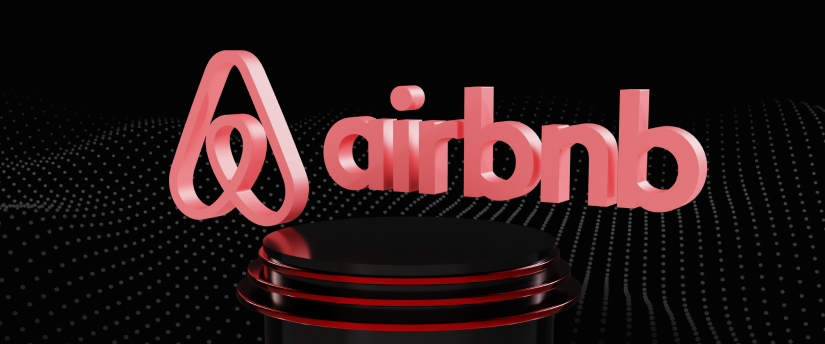

In [1]:
from IPython.display import Image
Image(filename='airbnb-logo.jpg') 

--------------------------------
--------------------------------
## **Import Libraries**
--------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_squared_error
from math import sqrt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pickle 

---------------------------------------
---------------------------------------

In [3]:
df = pd.read_csv('/kaggle/input/airbnb/Listings.csv',encoding='latin1')

/tmp/ipykernel_47/3951634749.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/airbnb/Listings.csv',encoding='latin1')


In [4]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,12/3/2011,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,11/29/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,7/31/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,12/17/2013,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,12/14/2014,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [5]:
df.shape

(279712, 33)

In [6]:
df['district'].value_counts()

district
Manhattan        16553
Brooklyn         14474
Queens            4704
Bronx              992
Staten Island      289
Name: count, dtype: int64

In [7]:
df.loc[df['city']=='Paris',['city','district']]

,city,district
0,Paris,NaN
1,Paris,NaN
2,Paris,NaN
3,Paris,NaN
4,Paris,NaN
...,...,...
279707,Paris,NaN
279708,Paris,NaN
279709,Paris,NaN
279710,Paris,NaN


In [8]:
df['city'].value_counts()

city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087
Name: count, dtype: int64

In [9]:
df.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [11]:
df.isnull().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [12]:
df=df.drop(['host_id','listing_id', 'name', 'host_response_rate', 'host_acceptance_rate','district','host_has_profile_pic',
           'maximum_nights','host_response_time','latitude', 'longitude'], axis = 1)

In [13]:
df.columns

Index(['host_since', 'host_location', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'neighbourhood',
       'city', 'property_type', 'room_type', 'accommodates', 'bedrooms',
       'amenities', 'price', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [14]:
df.duplicated().sum()

1783

In [15]:
df.drop_duplicates(inplace=True)

-----------------------------------------

In [16]:
df['price'].describe().T

count    277929.000000
mean        607.117487
std        3446.782242
min           0.000000
25%          75.000000
50%         150.000000
75%         466.000000
max      625216.000000
Name: price, dtype: float64

In [17]:
df.select_dtypes(include='object').describe()

,host_since,host_location,host_is_superhost,host_identity_verified,neighbourhood,city,property_type,room_type,amenities,instant_bookable
count,277766,277099,277766,277766,277929,277929,277929,277929,277929,277929
unique,4240,7159,2,2,660,10,144,4,245003,2
top,9/2/2019,"Paris, Ile-de-France, France",f,t,I Centro Storico,Paris,Entire apartment,Entire place,"[""Long term stays allowed""]",f
freq,710,47743,227811,200009,14779,64610,138591,181429,1380,163515


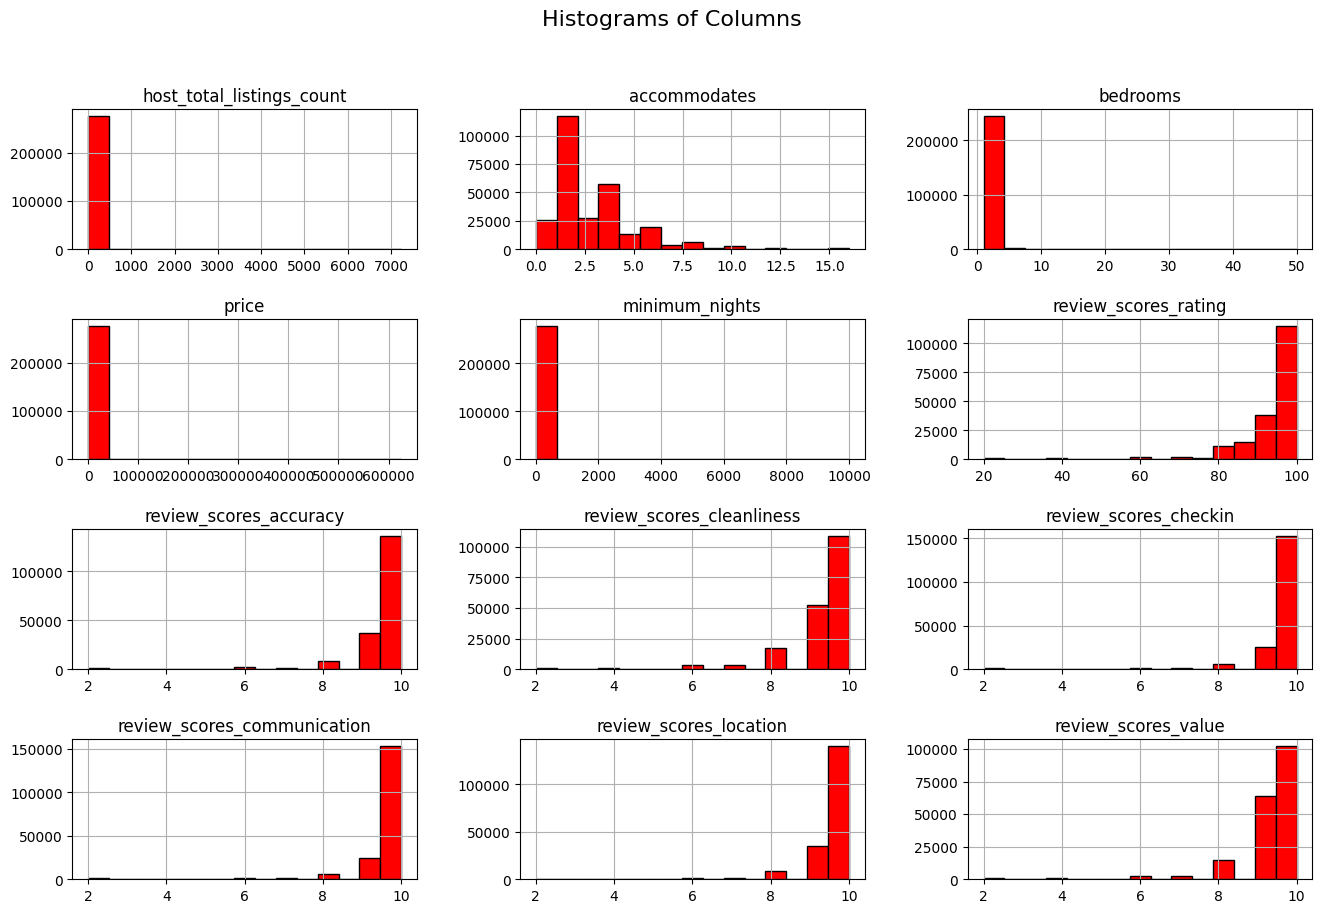

In [18]:
df.hist(bins=15, figsize=(16, 10), color='red', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  
plt.show()

-----------------------------
### **Checking Correlation between the features**
-----------------------------

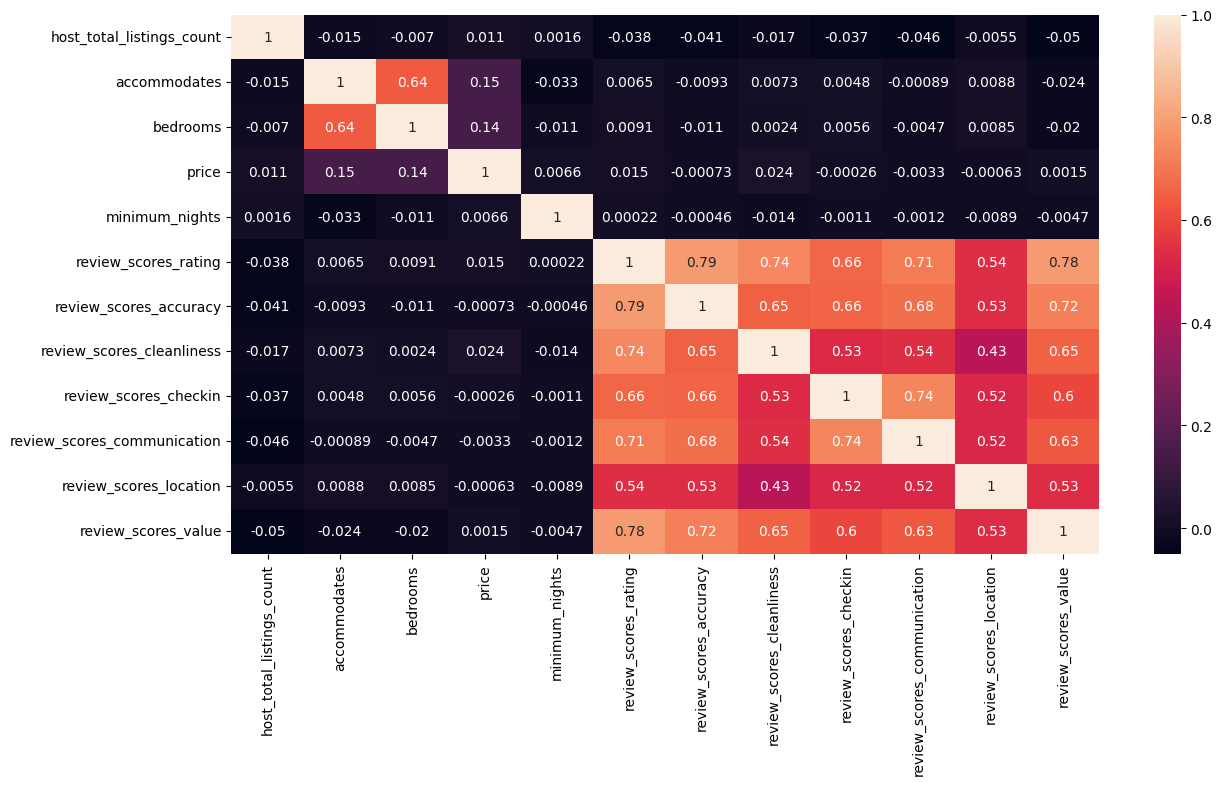

In [19]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


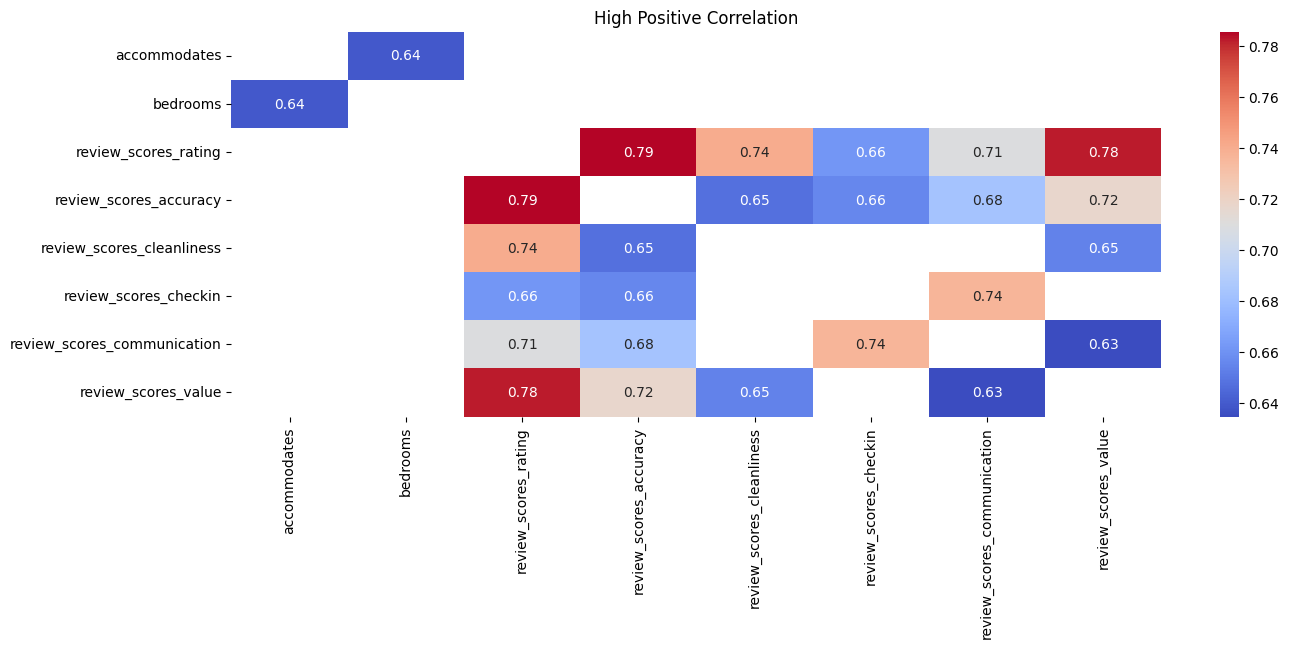

In [20]:
# # function to extract high positive correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr >= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# # get high positive correlated columns
high_corr = get_high_corr(df, 0.6)

 # plot high positive correlated columns
plt.figure(figsize=(15, 5))
plt.plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.plot.set_title('High Positive Correlation')
plt.show()

In [22]:
 # plot scatter plot for high correlated columns
def scatter(df, x, y):
     plt.figure(figsize=(14, 4))
     plt.ax = sns.scatterplot(x=x, y=y, data=df)
     #plt.ax.set_title(title)
     plt.show()

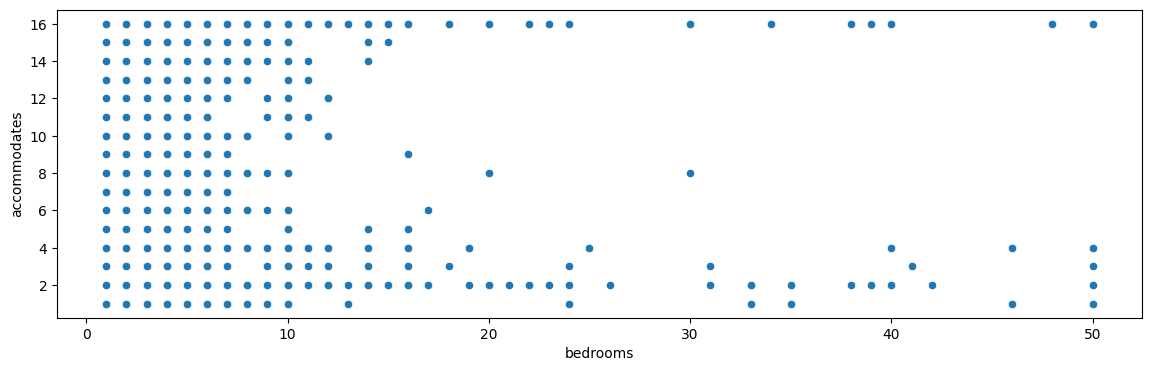

In [23]:
scatter(df, 'bedrooms', 'accommodates')

------------------
------------------
## **Detect Outliers**
-----------------

In [24]:
def kde(data,col):
    plt.figure(figsize=(12,	4))
    sns.kdeplot(data[col], fill=True,	color='green', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col,	fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [25]:
def boxplot(data,col):
    plt.fig, axes = plt.subplots(nrows=1,ncols=1)
    plt.fig.set_size_inches(14, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

In [26]:
df['price'].describe()

count    277929.000000
mean        607.117487
std        3446.782242
min           0.000000
25%          75.000000
50%         150.000000
75%         466.000000
max      625216.000000
Name: price, dtype: float64

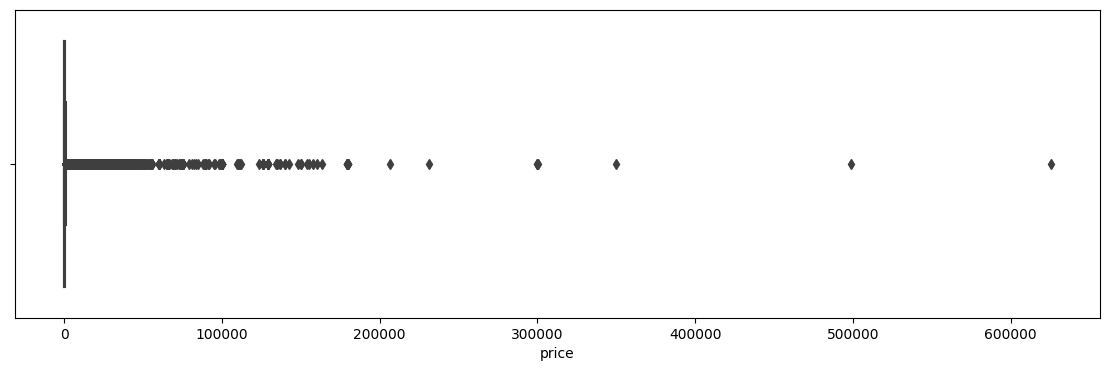

In [27]:
boxplot(df,'price')

----------------------------------------------

In [28]:
df['accommodates'].describe()

count    277929.000000
mean          3.293784
std           2.135077
min           0.000000
25%           2.000000
50%           2.000000
75%           4.000000
max          16.000000
Name: accommodates, dtype: float64

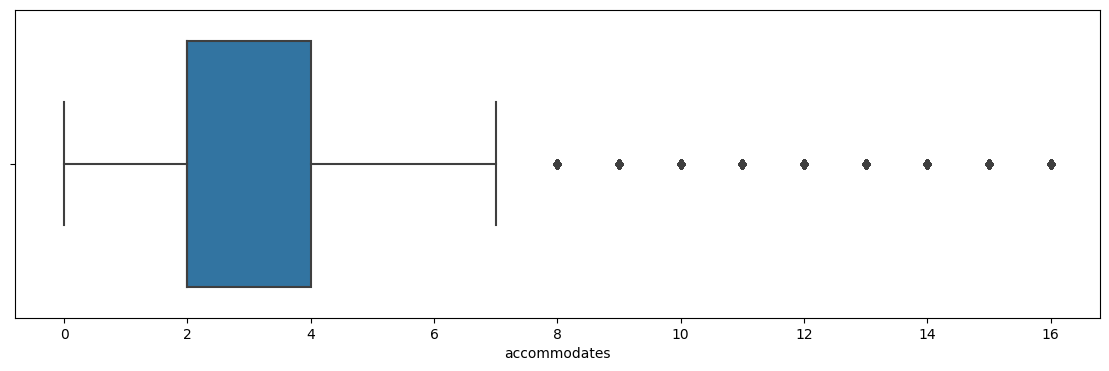

In [29]:
boxplot(df,'accommodates')

---------------------------

In [30]:
df['bedrooms'].describe()

count    248724.000000
mean          1.517634
std           1.155652
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          50.000000
Name: bedrooms, dtype: float64

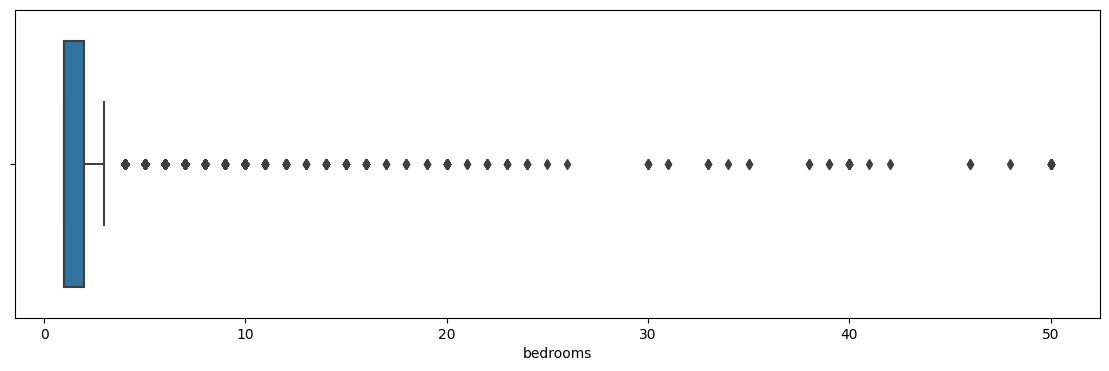

In [31]:
boxplot(df,'bedrooms')

-------------------------

In [32]:
df['minimum_nights'].describe()

count    277929.000000
mean          8.052567
std          31.585457
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max        9999.000000
Name: minimum_nights, dtype: float64

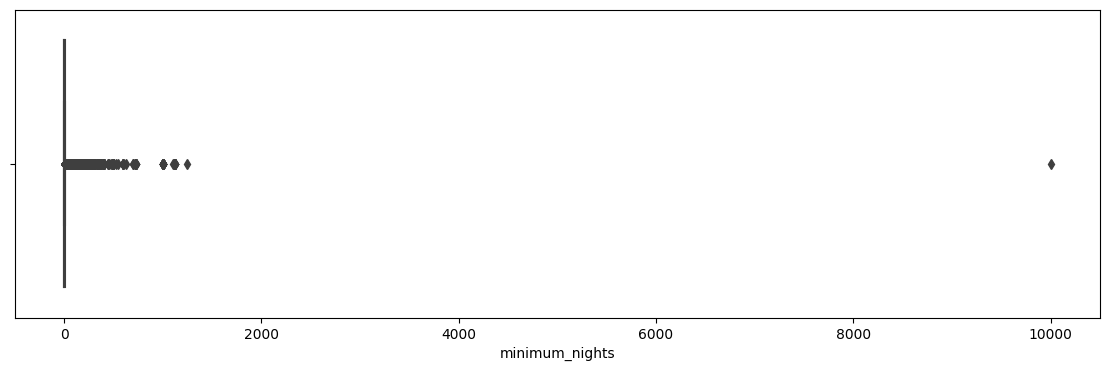

In [33]:
boxplot(df,'minimum_nights')

-------------------------
### **Remove outliers**
-------------------------

In [34]:
numerical_data=df[['price','accommodates','bedrooms','minimum_nights']]
for column in numerical_data.columns:
    Q1=numerical_data[column].quantile(0.25)
    Q3=numerical_data[column].quantile(0.75)
    IQR = Q3-Q1

    Lower_bound = Q1 - 1.5*IQR
    Upper_bound = Q3 + 1.5*IQR

    outliers = ((numerical_data[column]>Upper_bound)|(numerical_data[column]<Lower_bound)).sum()
    Total = numerical_data[column].shape[0]
    print(f'Total of outliers in {column} are   :   {outliers}--{round(100*(outliers)/Total,2)}%')
        
    if outliers > 0:
        df=df.loc[(df[column] <= Upper_bound) & (df[column] >= Lower_bound)]

Total of outliers in price are   :   31336--11.27%
Total of outliers in accommodates are   :   13571--4.88%
Total of outliers in bedrooms are   :   10190--3.67%
Total of outliers in minimum_nights are   :   42745--15.38%


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)


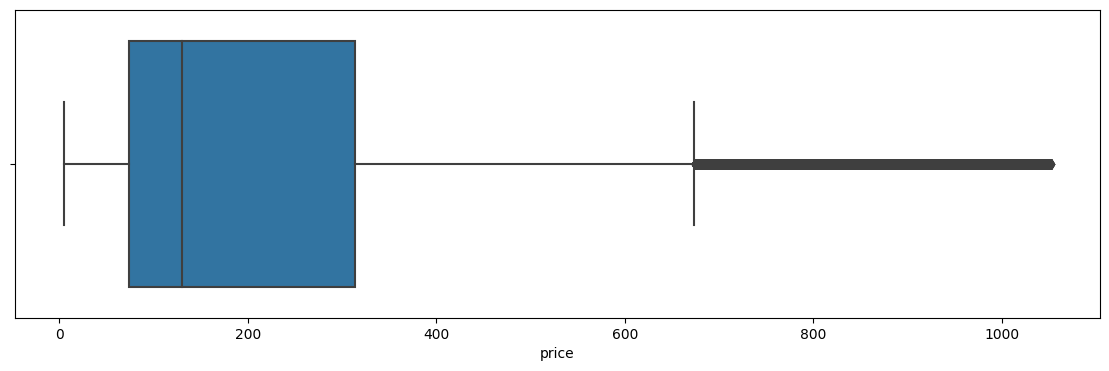

In [35]:
boxplot(df,'price')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


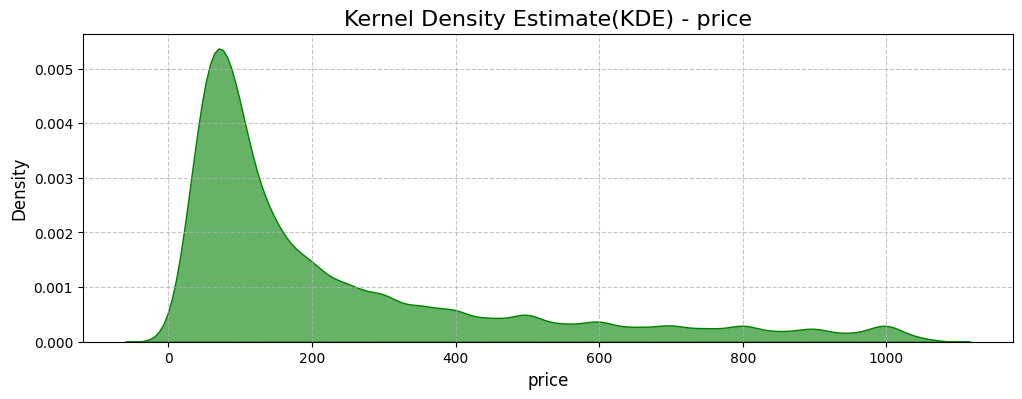

In [38]:
kde(df,'price')

-------------------------------

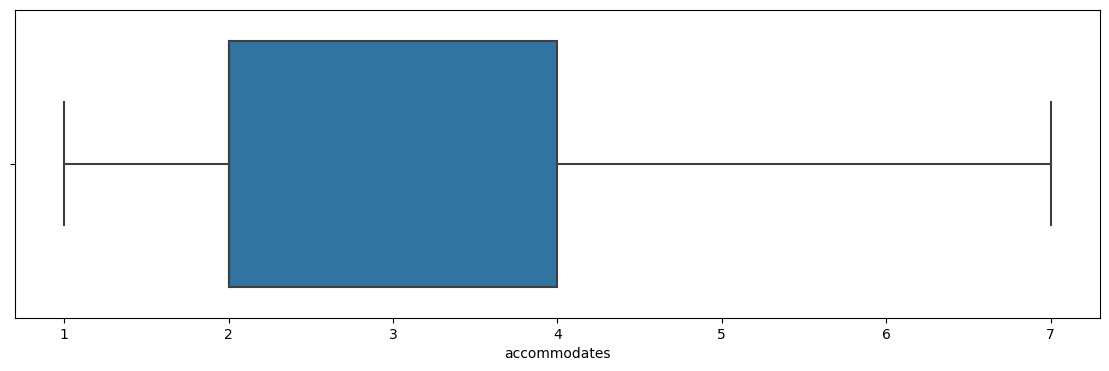

In [39]:
boxplot(df,'accommodates')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


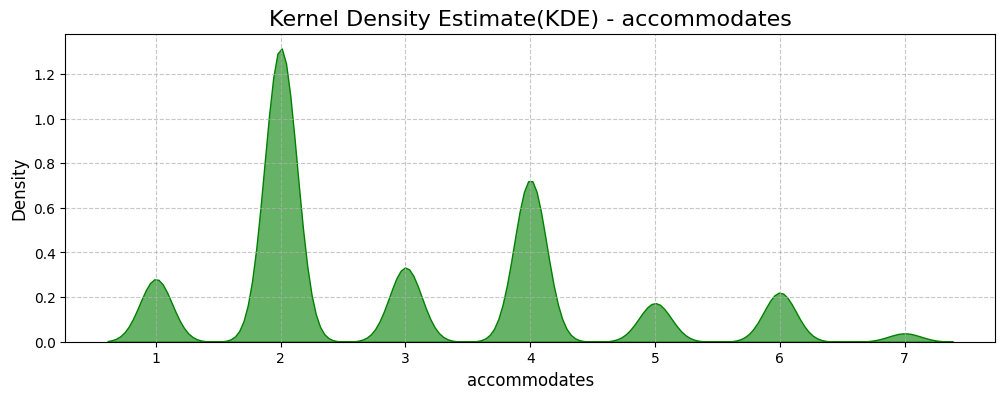

In [40]:
kde(df,'accommodates')

In [41]:
#df = df.loc[df['accommodates']<=6]

----------------------------------

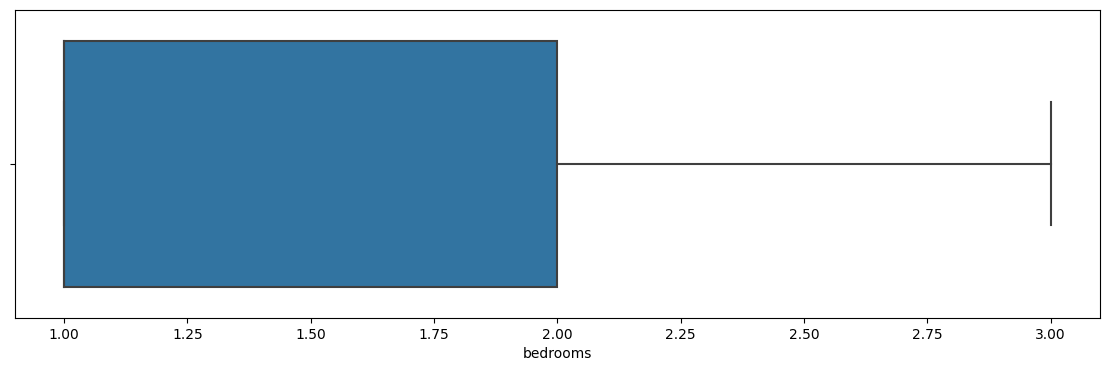

In [42]:
boxplot(df,'bedrooms')

In [43]:
df['bedrooms'].value_counts()

bedrooms
1.0    129824
2.0     36074
3.0      9230
Name: count, dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


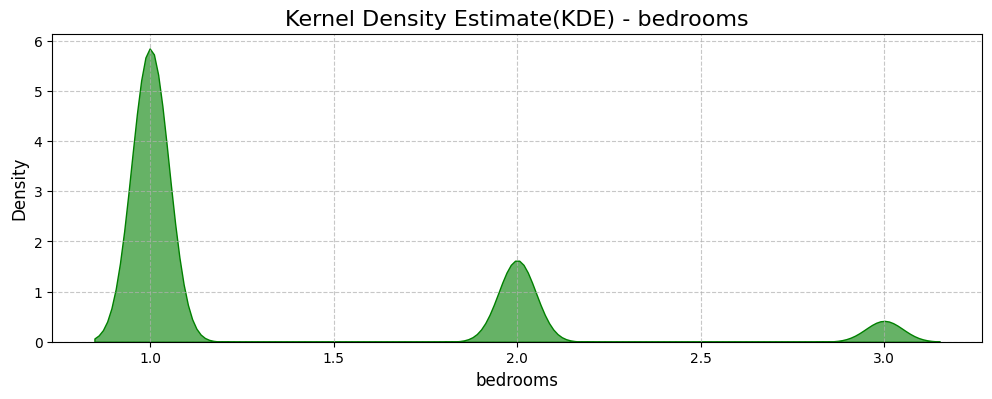

In [45]:
kde(df,'bedrooms')

----------------------

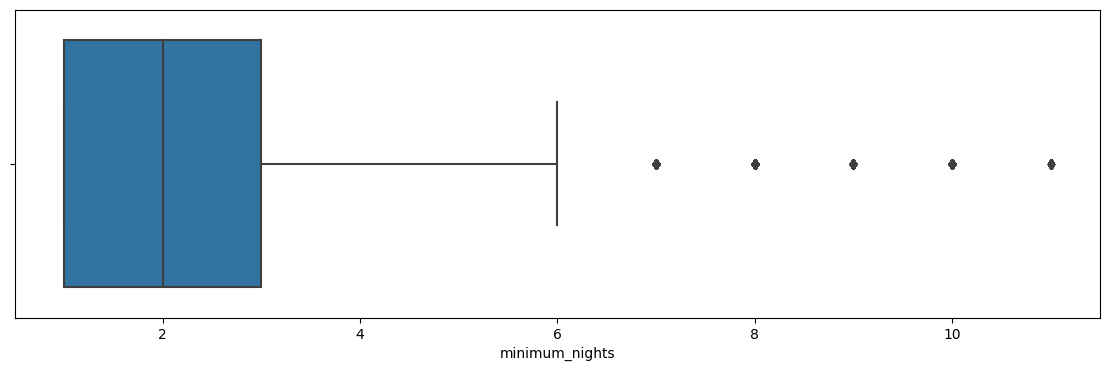

In [46]:
boxplot(df,'minimum_nights')

In [47]:
df['minimum_nights'].value_counts()

minimum_nights
1     67453
2     46468
3     28694
5     10083
4      9646
7      7828
6      2639
10     1791
8       349
9       145
11       32
Name: count, dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


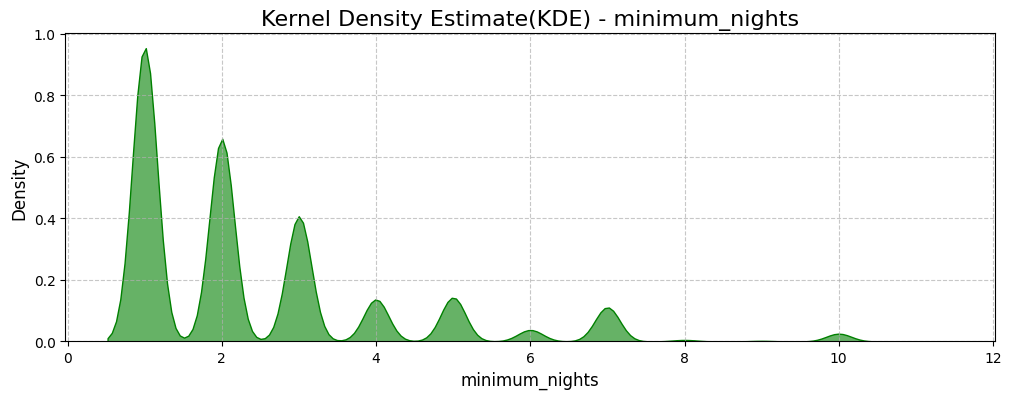

In [49]:
kde(df,'minimum_nights')

In [51]:
df.shape

(175128, 22)

------------------------------------------
## **Feature Extraction**
------------------------------------------

In [52]:
df.columns

Index(['host_since', 'host_location', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'neighbourhood',
       'city', 'property_type', 'room_type', 'accommodates', 'bedrooms',
       'amenities', 'price', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [56]:

key_amenities = [
    'Heating',
    'Kitchen',
    'Wifi',
    'Essentials',
    'Washer',
    'Long term stays allowed',
    'Smoke alarm',
    'Hair dryer',
    'Iron',
    'Dedicated workspace',
    'Hangers',
    'Hot water',
    'TV',
    'Cable TV',
    'Refrigerator',
    'Cooking basics',
    'Dishes and silverware',
    'Coffee maker',
    'Dishwasher',
    'Microwave',
    'Carbon monoxide alarm',
    'Fire extinguisher',
    'First aid kit',
    'Shampoo',
    'Elevator',
    'Paid parking off premises',
    'Free street parking',
    'Bathtub'
]

for amenity in key_amenities:
    df[amenity] = df['amenities'].apply(lambda x: 1 if amenity in str(x) else 0)


In [57]:
df.columns

Index(['host_since', 'host_location', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'neighbourhood',
       'city', 'property_type', 'room_type', 'accommodates', 'bedrooms',
       'amenities', 'price', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'Heating', 'Kitchen', 'Wifi', 'Essentials', 'Washer',
       'Long term stays allowed', 'Smoke alarm', 'Hair dryer', 'Iron',
       'Dedicated workspace', 'Hangers', 'Hot water', 'TV', 'Cable TV',
       'Refrigerator', 'Cooking basics', 'Dishes and silverware',
       'Coffee maker', 'Dishwasher', 'Microwave', 'Carbon monoxide alarm',
       'Fire extinguisher', 'First aid kit', 'Shampoo', 'Elevator',
       'Paid parking off premises', 'Free street parking', 'Bathtub'],
      dtype='object')

In [58]:
df.shape

(175128, 50)

In [59]:
df['property_type'].value_counts()

property_type
Entire apartment             87113
Private room in apartment    32304
Private room in house        10302
Entire condominium            5488
Entire house                  4885
                             ...  
Private room in tipi             1
Cave                             1
Entire vacation home             1
Shared room in pension           1
Pension                          1
Name: count, Length: 136, dtype: int64

In [60]:
df.isnull().sum()

host_since                       102
host_location                    469
host_is_superhost                102
host_total_listings_count        102
host_identity_verified           102
neighbourhood                      0
city                               0
property_type                      0
room_type                          0
accommodates                       0
bedrooms                           0
amenities                          0
price                              0
minimum_nights                     0
review_scores_rating           51157
review_scores_accuracy         51363
review_scores_cleanliness      51336
review_scores_checkin          51390
review_scores_communication    51338
review_scores_location         51393
review_scores_value            51394
instant_bookable                   0
Heating                            0
Kitchen                            0
Wifi                               0
Essentials                         0
Washer                             0
L

In [61]:
df.columns

Index(['host_since', 'host_location', 'host_is_superhost',
       'host_total_listings_count', 'host_identity_verified', 'neighbourhood',
       'city', 'property_type', 'room_type', 'accommodates', 'bedrooms',
       'amenities', 'price', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'Heating', 'Kitchen', 'Wifi', 'Essentials', 'Washer',
       'Long term stays allowed', 'Smoke alarm', 'Hair dryer', 'Iron',
       'Dedicated workspace', 'Hangers', 'Hot water', 'TV', 'Cable TV',
       'Refrigerator', 'Cooking basics', 'Dishes and silverware',
       'Coffee maker', 'Dishwasher', 'Microwave', 'Carbon monoxide alarm',
       'Fire extinguisher', 'First aid kit', 'Shampoo', 'Elevator',
       'Paid parking off premises', 'Free street parking', 'Bathtub'],
      dtype='object')

In [62]:
df= df.drop(['host_location','amenities','neighbourhood','host_since','review_scores_checkin','review_scores_communication' ], axis=1)

In [64]:
property_categories = {
    "ENTIRE_SPACE": [
        'Entire apartment', 'Entire loft', 'Entire house', 'Entire condominium',
        'Entire townhouse', 'Entire serviced apartment', 'Entire bungalow',
        'Entire villa', 'Entire guest suite', 'Entire cottage',
        'Entire guesthouse', 'Entire chalet', 'Entire bed and breakfast',
        'Entire cabin', 'Entire tent', 'Entire hostel',
        'Entire home/apt', 'Entire resort', 'Entire dorm',
        'Entire vacation home', 'Entire floor', 'Entire in-law'
    ],
    "PRIVATE_ROOM": [
        'Private room in apartment', 'Private room in townhouse',
        'Private room in house', 'Private room in condominium',
        'Private room in guesthouse', 'Private room in serviced apartment',
        'Private room in villa', 'Private room in guest suite',
        'Private room in hostel', 'Private room in loft',
        'Private room in cabin', 'Private room in chalet',
        'Private room in cottage', 'Private room in yurt',
        'Private room in hut', 'Private room in resort',
        'Private room in bungalow', 'Private room in houseboat',
        'Private room in farm stay', 'Private room in pousada',
        'Private room in dorm', 'Private room in pension',
        'Private room in tipi', 'Private room in boat',
        'Private room in treehouse', 'Private room in cave',
        'Private room in lighthouse', 'Private room in barn',
        'Private room in bus', 'Private room in minsu',
        'Private room', 'Private room in island', 'Private room in dome house',
        'Private room in earth house', 'Private room in kezhan',
        'Private room in in-law'
    ],
"SHARED_ROOM": [
        'Shared room in apartment', 'Shared room in condominium',
        'Shared room in house', 'Shared room in townhouse',
        'Shared room in guesthouse', 'Shared room in chalet',
        'Shared room in boutique hotel', 'Shared room in bed and breakfast',
        'Shared room in hostel', 'Shared room in dorm',
        'Shared room in yurt', 'Shared room in boat',
        'Shared room in tiny house', 'Shared room in train',
        'Shared room', 'Shared room in island', 'Shared room in tent',
        'Shared room in cave', 'Shared room in tipi', 'Shared room in hut',
        'Shared room in cabin', 'Shared room in farm stay',
        'Shared room in resort', 'Shared room in bungalow',
        'Shared room in serviced apartment'
    ],

    "SPECIAL_UNIQUE": [
        'Treehouse', 'Yurt', 'Camper/RV', 'Boat', 'Houseboat',
        'Farm stay', 'Barn', 'Campsite', 'Tiny house', 'Castle',
        'Island', 'Dome house', 'Lighthouse', 'Earth house',
        'Bus', 'Igloo', 'Train', 'Tent', 'Windmill',
        'Cave', 'Pension', 'Holiday park'
    ],

    "HOTEL_STYLE": [
        'Room in aparthotel', 'Room in serviced apartment', 'Room in hotel',
        'Room in boutique hotel', 'Room in bed and breakfast',
        'Room in resort', 'Room in hostel', 'Room in nature lodge',
        'Room in guesthouse', 'Room in pension', 'Room in casa particular',
        'Room in heritage hotel', 'Holiday park'
    ],
"CAMPING_OUTDOOR": [
        'Campsite', 'Tent', 'Tipi', 'Yurt', 'Treehouse', 'Igloo'
    ]
}


def categorize_property(ptype):
    for category, items in property_categories.items():
        if ptype in items:
            return category
    return "OTHER"


df['property_category'] = df['property_type'].apply(categorize_property)

In [65]:
df=df.drop('property_type',axis=1)

In [66]:
num_col = ['review_scores_rating','review_scores_accuracy', 
            'review_scores_cleanliness','review_scores_location', 'review_scores_value']

for col in num_col:
    df[col].fillna(df[col].median(), inplace=True) 

/tmp/ipykernel_47/1610286781.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [67]:
df['review_scores_rating'] = df['review_scores_rating'].apply(lambda x : int(round(x/10)))
df['review_scores_rating'].value_counts()

review_scores_rating
10    127585
9      33206
8       9980
7       1510
6       1472
2        709
4        430
5        216
3         20
Name: count, dtype: int64

In [73]:
df.isnull().sum()

host_is_superhost            102
host_total_listings_count    102
host_identity_verified       102
city                           0
room_type                      0
accommodates                   0
bedrooms                       0
price                          0
minimum_nights                 0
review_scores_rating           0
review_scores_accuracy         0
review_scores_cleanliness      0
review_scores_location         0
review_scores_value            0
instant_bookable               0
Heating                        0
Kitchen                        0
Wifi                           0
Essentials                     0
Washer                         0
Long term stays allowed        0
Smoke alarm                    0
Hair dryer                     0
Iron                           0
Dedicated workspace            0
Hangers                        0
Hot water                      0
TV                             0
Cable TV                       0
Refrigerator                   0
Cooking ba

In [74]:
df = df.dropna()

In [75]:
df.isnull().sum()

host_is_superhost            0
host_total_listings_count    0
host_identity_verified       0
city                         0
room_type                    0
accommodates                 0
bedrooms                     0
price                        0
minimum_nights               0
review_scores_rating         0
review_scores_accuracy       0
review_scores_cleanliness    0
review_scores_location       0
review_scores_value          0
instant_bookable             0
Heating                      0
Kitchen                      0
Wifi                         0
Essentials                   0
Washer                       0
Long term stays allowed      0
Smoke alarm                  0
Hair dryer                   0
Iron                         0
Dedicated workspace          0
Hangers                      0
Hot water                    0
TV                           0
Cable TV                     0
Refrigerator                 0
Cooking basics               0
Dishes and silverware        0
Coffee m

In [76]:
df.duplicated().sum()

1288

In [77]:
df.drop_duplicates(inplace = True)

In [78]:
df.shape

(173738, 44)

In [79]:
data_for_test = df.iloc[173700:,:]

In [80]:
data_for_test.to_excel('data_for_test.xlsx',index=False)

In [81]:
df = df.iloc[:173700,:]

---------------------
## **Transform data**
---------------------

In [82]:
data_obj = df.select_dtypes('object')
data_non_obj = df.select_dtypes('number')

In [83]:
data_obj.head()

,host_is_superhost,host_identity_verified,city,room_type,instant_bookable,property_category
0,f,f,Paris,Entire place,f,ENTIRE_SPACE
1,f,t,Paris,Entire place,f,ENTIRE_SPACE
2,f,f,Paris,Entire place,f,ENTIRE_SPACE
3,f,t,Paris,Entire place,f,ENTIRE_SPACE
4,f,f,Paris,Entire place,f,ENTIRE_SPACE


In [84]:
df_object_for_ohe = data_obj[['instant_bookable','host_identity_verified','host_is_superhost']].columns

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = ohe.fit_transform(data_obj[df_object_for_ohe])
one_hot_columns = ohe.get_feature_names_out(df_object_for_ohe)
df_ohe = pd.DataFrame(one_hot_encoded, columns=one_hot_columns, index=df.index)
df_for_ohe = data_obj.drop(columns=df_object_for_ohe).join(df_ohe)

In [85]:
with open('One_Hot_Encoder.pkl', 'wb') as f:
     pickle.dump(ohe, f)

In [86]:
df_for_ohe.columns

Index(['city', 'room_type', 'property_category', 'instant_bookable_f',
       'instant_bookable_t', 'host_identity_verified_f',
       'host_identity_verified_t', 'host_is_superhost_f',
       'host_is_superhost_t'],
      dtype='object')

In [87]:
df_for_ohe = df_for_ohe.drop(['instant_bookable_t','host_identity_verified_t','host_is_superhost_t'],axis=1)

In [88]:
categorical_cols = df_for_ohe[['city','room_type','property_category']]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_for_ohe[col] = le.fit_transform(df_for_ohe[col].astype(str))
    label_encoders[col] = le

In [89]:
mapping = {category : index for index, category in enumerate(label_encoders['property_category'].classes_)}
print(mapping)

{'ENTIRE_SPACE': 0, 'HOTEL_STYLE': 1, 'OTHER': 2, 'PRIVATE_ROOM': 3, 'SHARED_ROOM': 4, 'SPECIAL_UNIQUE': 5}


In [90]:
with open('label_encoders.pkl','wb') as f:
     pickle.dump(le, f)

In [91]:
df = pd.concat([data_non_obj,df_for_ohe],axis=1)

In [92]:
df.head()

,host_total_listings_count,accommodates,bedrooms,price,minimum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_location,review_scores_value,...,Elevator,Paid parking off premises,Free street parking,Bathtub,city,room_type,property_category,instant_bookable_f,host_identity_verified_f,host_is_superhost_f
0,1.0,2,1.0,53,2,10,10.0,10.0,10.0,10.0,...,0,0,0,0,6,0,0,1.0,1.0,1.0
1,1.0,2,1.0,120,2,10,10.0,10.0,10.0,10.0,...,0,0,0,0,6,0,0,1.0,0.0,1.0
2,1.0,2,1.0,89,2,10,10.0,10.0,10.0,10.0,...,0,0,0,0,6,0,0,1.0,1.0,1.0
3,1.0,2,1.0,58,2,10,10.0,10.0,10.0,10.0,...,0,0,0,0,6,0,0,1.0,0.0,1.0
4,1.0,2,1.0,60,2,10,10.0,10.0,10.0,10.0,...,1,0,0,1,6,0,0,1.0,1.0,1.0


In [93]:
df.shape

(173700, 44)

-----------------------------
## **Creating Model**
------------------------
### **Spliting Data to train and test**
-----------------------

In [94]:
x = df.drop('price',axis=1)
y = df['price']
y = np.log(y).replace(-np.inf,1e-6)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_test : {x_test.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_test : {y_test.shape}')

shape of x_train : (156330, 43)
shape of x_test : (17370, 43)
-------------------------------
shape of y_train : (156330,)
shape of y_test : (17370,)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


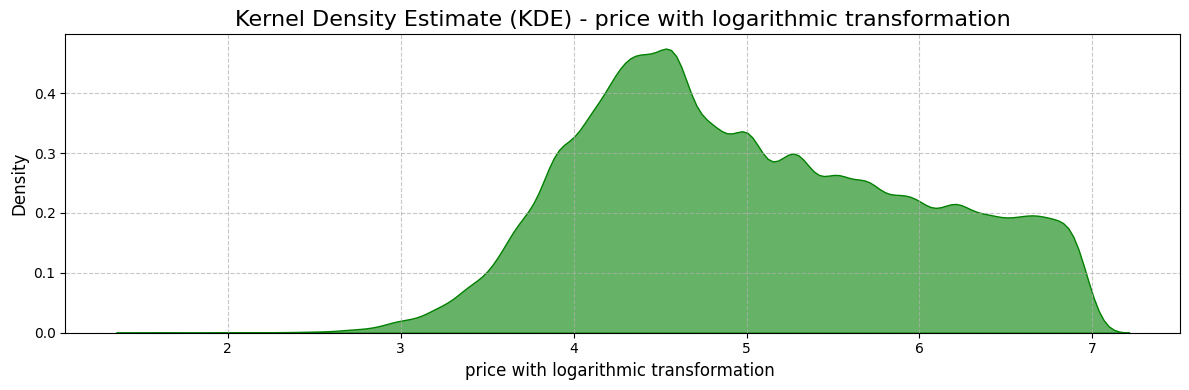

In [95]:
plt.figure(figsize=(12, 4))  
sns.kdeplot(y, fill=True, color='green', alpha=0.6)  
plt.title(f'Kernel Density Estimate (KDE) - price with logarithmic transformation', fontsize=16)  
plt.xlabel('price with logarithmic transformation ', fontsize=12)  
plt.ylabel('Density', fontsize=12) 
plt.grid(True, linestyle='--', alpha=0.7)  
plt.tight_layout()  
plt.show()

---------------------------
### **Cross validation**
---------------------------

In [ ]:
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf = RandomForestRegressor()

scores_rf = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

xgb = XGBRegressor()

scores_xgb = cross_val_score(
    xgb,
    x_train,
    y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

In [97]:
print(f"Random Forest RMSE: {-scores_rf.mean():.2f}")
print(f"XGBoost RMSE: {-scores_xgb.mean():.2f}")

Random Forest RMSE: 0.45
XGBoost RMSE: 0.44


In [98]:
xgb=xgb.fit(x_train, y_train)
rf=rf.fit(x_train, y_train)

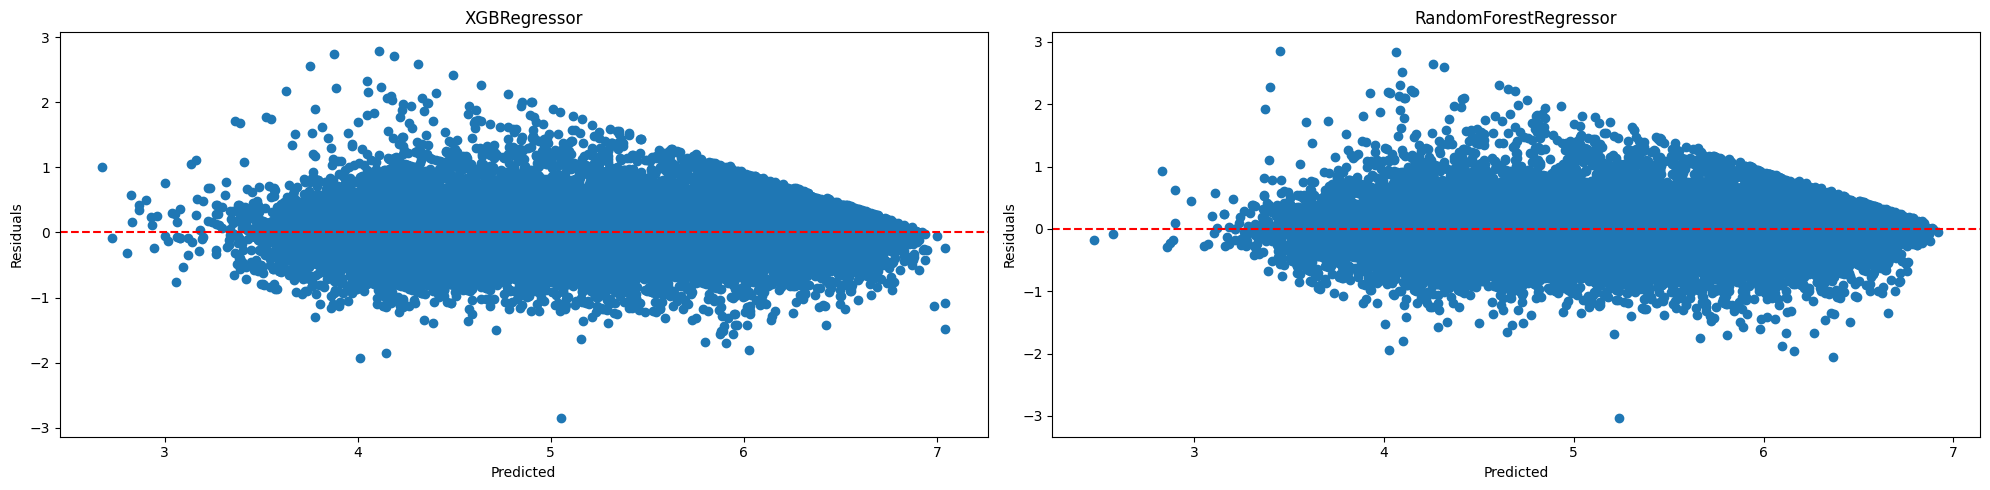

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))  

residuals_xgb = y_test - xgb.predict(x_test)
axes[0].scatter(xgb.predict(x_test), residuals_xgb)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("XGBRegressor")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_dt = y_test - rf.predict(x_test)
axes[1].scatter(rf.predict(x_test), residuals_dt)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("RandomForestRegressor")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [100]:
with open('XGBRegressor_model.pkl' , 'wb') as f :
   pickle.dump(xgb, f)

In [101]:
with open('RandomForestRegressor_model.pkl' , 'wb') as f :
    pickle.dump(rf, f)

-----------------------
### **Testing Model**
----------------------

In [102]:
with open('XGBRegressor_model.pkl','rb') as f : 
    XGBRegressor_model = pickle.load(f)

In [103]:
with open('RandomForestRegressor_model.pkl','rb') as f : 
    RandomForestRegressor_model = pickle.load(f)

------------------------------------------

In [104]:
y_predict = XGBRegressor_model.predict(x_test)

In [105]:
y_predict2 = RandomForestRegressor_model.predict(x_test)

---------------------------
### **Feature importances**
---------------------------

In [106]:
Importance = XGBRegressor_model.feature_importances_
indices = np.argsort(Importance)[::-1]

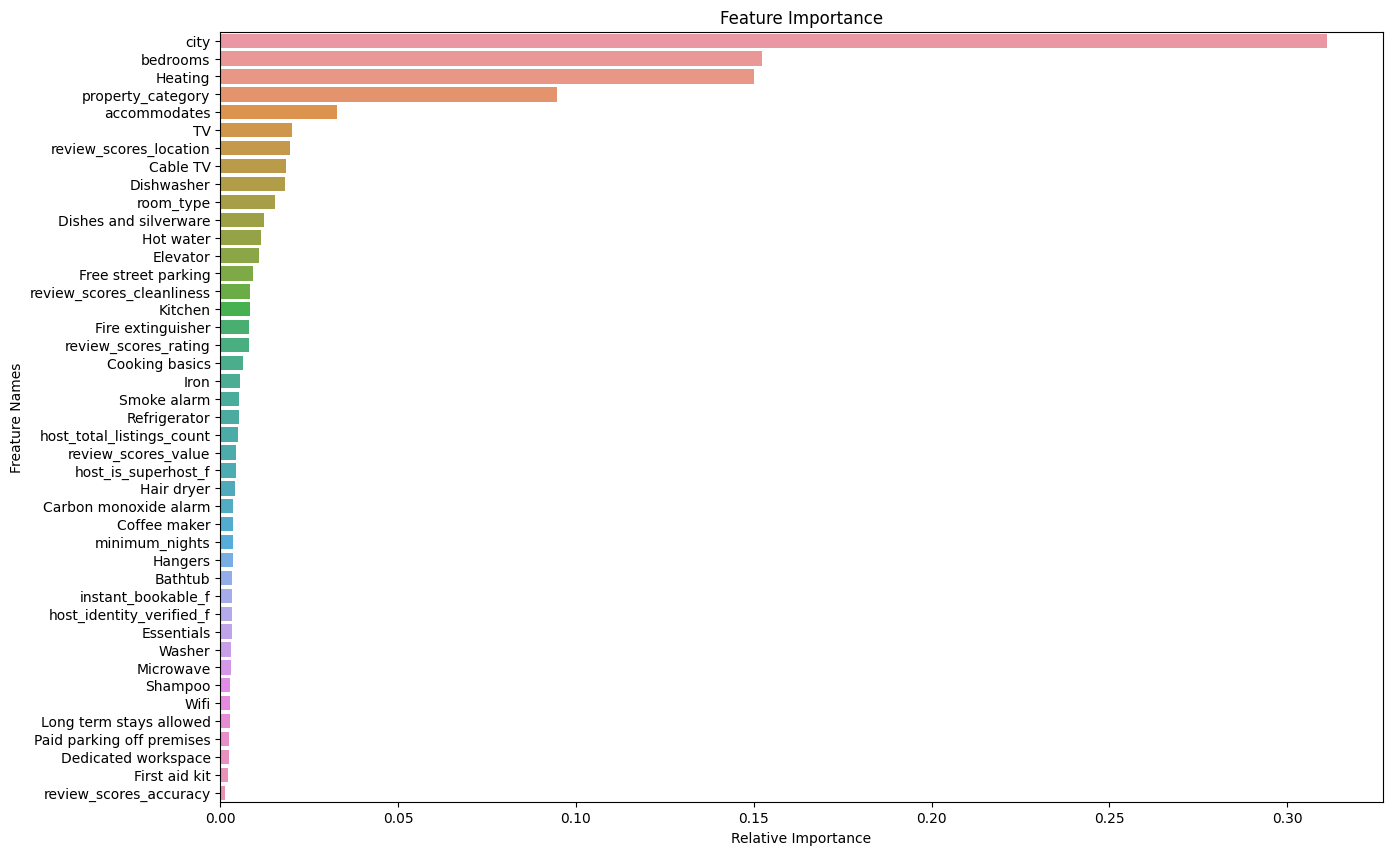

In [107]:
plt.figure(figsize=(15, 10))
sns.barplot(x = Importance[indices], y = x.columns[indices])
plt.title('Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Freature Names')
plt.show()

In [108]:
Importance2 = RandomForestRegressor_model.feature_importances_
indices2 = np.argsort(Importance2)[::-1]

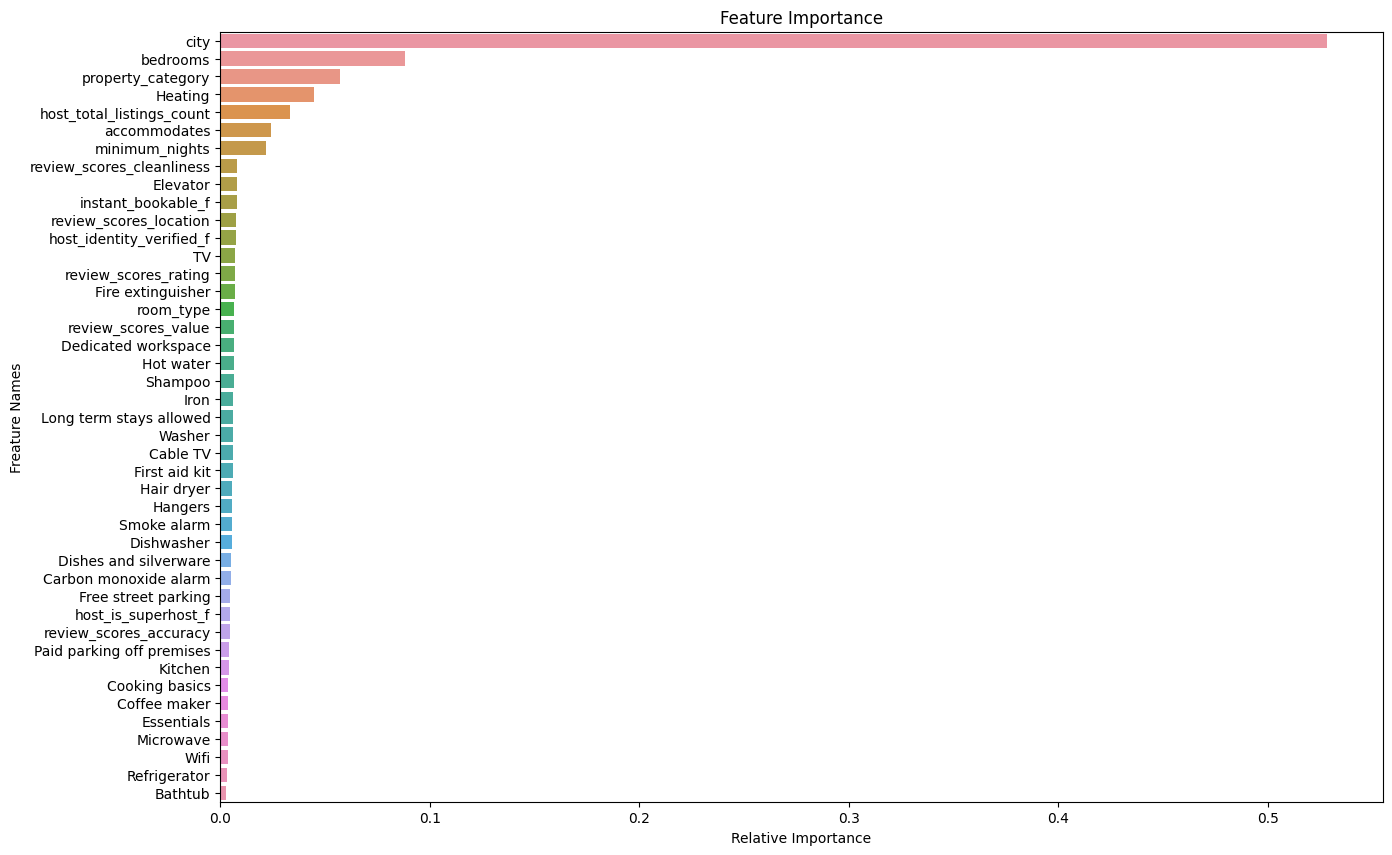

In [109]:
plt.figure(figsize=(15, 10))
sns.barplot(x = Importance2[indices2], y = x.columns[indices2])
plt.title('Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Freature Names')
plt.show()

In [110]:
data_test = pd.read_excel('/kaggle/working/data_for_test.xlsx')
data_test.head()

,host_is_superhost,host_total_listings_count,host_identity_verified,city,room_type,accommodates,bedrooms,price,minimum_nights,review_scores_rating,...,Microwave,Carbon monoxide alarm,Fire extinguisher,First aid kit,Shampoo,Elevator,Paid parking off premises,Free street parking,Bathtub,property_category
0,f,1,t,Paris,Entire place,2,1,88,3,10,...,0,1,0,0,1,0,0,0,0,ENTIRE_SPACE
1,f,1,t,Paris,Entire place,2,1,120,3,10,...,1,0,1,1,1,0,1,1,0,ENTIRE_SPACE
2,f,1,t,Paris,Entire place,2,1,90,3,10,...,1,0,0,0,0,0,0,0,0,ENTIRE_SPACE
3,f,1,t,Paris,Entire place,2,1,85,2,10,...,1,0,0,0,0,0,0,0,0,ENTIRE_SPACE
4,f,1,t,Paris,Entire place,2,1,150,2,10,...,0,1,0,0,1,0,0,0,0,ENTIRE_SPACE


In [111]:
original_data_test = data_test.copy()

In [112]:
original_data_test2 = data_test.copy()

In [113]:
with open("One_Hot_Encoder.pkl", "rb") as f:
    ohe = pickle.load(f)
    
ohe_columns = ['instant_bookable','host_identity_verified','host_is_superhost']  
ohe_encoded_data = ohe.transform(data_test[ohe_columns])
ohe_encoded_data_df = pd.DataFrame(ohe_encoded_data, columns=ohe.get_feature_names_out(ohe_columns), index=data_test.index)
df2 = pd.concat([data_test, ohe_encoded_data_df], axis=1)
df2.drop(columns=ohe_columns, inplace=True)

In [114]:
df2 = df2.drop(['instant_bookable_t', 'host_identity_verified_t','host_is_superhost_t'],axis=1)

In [115]:
with open("label_encoders.pkl", "rb") as f:
    label = pickle.load(f)

label_encoder_columns = ['city','room_type','property_category']
for col in label_encoder_columns:
    if col in label_encoders:  
        label = label_encoders[col]
    
        unseen_values = set(df2[col]) - set(label.classes_)
        if unseen_values:
            label.classes_ = append(label.classes_, list(unseen_values))  

        df2[col] = label.transform(df2[col])
    else:
        print(f"Warning: No encoder found for column {col}")

In [116]:
df2 = df2.drop('price', axis=1)

In [117]:
df2.columns

Index(['host_total_listings_count', 'city', 'room_type', 'accommodates',
       'bedrooms', 'minimum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_location', 'review_scores_value', 'Heating', 'Kitchen',
       'Wifi', 'Essentials', 'Washer', 'Long term stays allowed',
       'Smoke alarm', 'Hair dryer', 'Iron', 'Dedicated workspace', 'Hangers',
       'Hot water', 'TV', 'Cable TV', 'Refrigerator', 'Cooking basics',
       'Dishes and silverware', 'Coffee maker', 'Dishwasher', 'Microwave',
       'Carbon monoxide alarm', 'Fire extinguisher', 'First aid kit',
       'Shampoo', 'Elevator', 'Paid parking off premises',
       'Free street parking', 'Bathtub', 'property_category',
       'instant_bookable_f', 'host_identity_verified_f',
       'host_is_superhost_f'],
      dtype='object')

In [118]:
df.columns

Index(['host_total_listings_count', 'accommodates', 'bedrooms', 'price',
       'minimum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'Heating', 'Kitchen', 'Wifi', 'Essentials',
       'Washer', 'Long term stays allowed', 'Smoke alarm', 'Hair dryer',
       'Iron', 'Dedicated workspace', 'Hangers', 'Hot water', 'TV', 'Cable TV',
       'Refrigerator', 'Cooking basics', 'Dishes and silverware',
       'Coffee maker', 'Dishwasher', 'Microwave', 'Carbon monoxide alarm',
       'Fire extinguisher', 'First aid kit', 'Shampoo', 'Elevator',
       'Paid parking off premises', 'Free street parking', 'Bathtub', 'city',
       'room_type', 'property_category', 'instant_bookable_f',
       'host_identity_verified_f', 'host_is_superhost_f'],
      dtype='object')

In [119]:
df2 = df2[['host_total_listings_count', 'accommodates', 'bedrooms',
       'minimum_nights', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_location',
       'review_scores_value', 'Heating', 'Kitchen', 'Wifi', 'Essentials',
       'Washer', 'Long term stays allowed', 'Smoke alarm', 'Hair dryer',
       'Iron', 'Dedicated workspace', 'Hangers', 'Hot water', 'TV', 'Cable TV',
       'Refrigerator', 'Cooking basics', 'Dishes and silverware',
       'Coffee maker', 'Dishwasher', 'Microwave', 'Carbon monoxide alarm',
       'Fire extinguisher', 'First aid kit', 'Shampoo', 'Elevator',
       'Paid parking off premises', 'Free street parking', 'Bathtub', 'city',
       'room_type', 'property_category', 'instant_bookable_f',
       'host_identity_verified_f', 'host_is_superhost_f']]

In [120]:
new_predictions = XGBRegressor_model.predict(df2)

In [121]:
new_predictions2 = RandomForestRegressor_model.predict(df2)

In [122]:
new_predictions = np.exp(new_predictions)

In [123]:
new_predictions2 = np.exp(new_predictions2)

In [124]:
original_data_test['XGB_Predicted price'] = new_predictions

In [143]:
original_data_test[['price','XGB_Predicted price']].sample(5)

,price,XGB_Predicted price
13,105,67.290665
11,80,85.728775
37,70,85.437073
14,65,66.540047
20,80,89.807434


In [221]:
original_data_test2['Rn_Predicted price'] = new_predictions2

In [225]:
original_data_test2[['price','Rn_Predicted price']].sample(5)

,price,Rn_Predicted price
25,85,72.830511
22,80,63.245328
3,85,80.877878
26,80,64.849257
18,80,85.826960


---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "Airbnb price prediction.ipynb"

[NbConvertApp] Converting notebook Airbnb price prediction.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 1987851 bytes to Airbnb price prediction.html
